### [ 연속 영역 분할 1 : 거리 변환 (distance_transform)] <hr>
- 작은 이진 이미지를 만들어 각 전경 픽섹이 가장 가까운 배경까지 얼마나 떨어져 있는지 확인
- 배경 픽셀 : `0`
- 전경 픽셀 : `255`
- 중심으로 갈수록 거리 값이 커짐

In [1]:
import cv2
import numpy as np
import sys
sys.path.append('..')
from cv_utils import *

- [1] 임의 픽셀로 이진 이미지 만들기

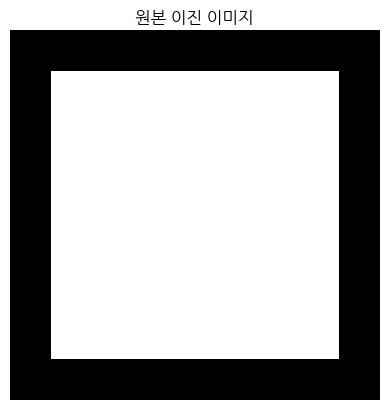

In [8]:
# 좌우 상하 - 배경으로 0
# 가운데 - 전경으로 255
image = np.zeros((9,9), dtype=np.uint8)
image[1:8, 1:8] = 255

plt.imshow(image, cmap='gray');
plt.title('원본 이진 이미지');
plt.axis('off');
# printPlots(1,1 ['원본 이진 이미지'], [image], ['gray'])

- [2] 거리

거리 변환 결과
[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 1. 2. 2. 2. 2. 2. 1. 0.]
 [0. 1. 2. 3. 3. 3. 2. 1. 0.]
 [0. 1. 2. 3. 4. 3. 2. 1. 0.]
 [0. 1. 2. 3. 3. 3. 2. 1. 0.]
 [0. 1. 2. 2. 2. 2. 2. 1. 0.]
 [0. 1. 1. 1. 1. 1. 1. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


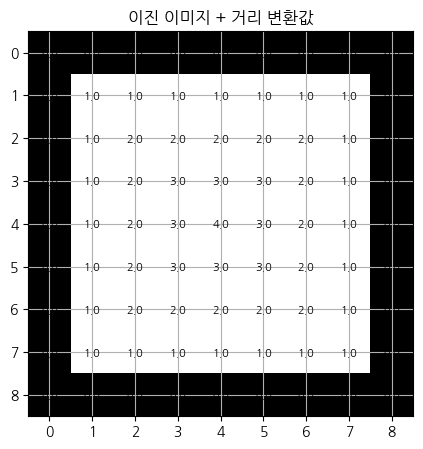

In [11]:
# 변환 방식 : cv2.DIST_L2
distance = cv2.distanceTransform(image, cv2.DIST_L2, 5)
print("거리 변환 결과", distance, sep="\n")

# => 시각화
printDistance(image, distance, "이진 이미지 + 거리 변환값")

### [핵심정리]
- 거리 변환은 객체 내부에서 배경으로부터 가장 먼 부분을 찾는데 유용
- 활용 예
    * 객체 중심점 찾기
    * 손바닥 중심 찾기
    * 서로 붙은 객체를 워터셰드로 분리하기 위한 전경 마커 생성